# 🧠 RecycleVision — Model Training (5 Transfer Learning Models)
**Project:** Garbage Image Classification Using Deep Learning  
**Notebook:** 03_Model_Training.ipynb  
**Models:** MobileNetV2 | EfficientNetB0 | ResNet50 | VGG16 | InceptionV3  
**Goal:** Train all 5 models and save them for evaluation

## 🔲 Cell 1 — Import Libraries

In [1]:
# Cell 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# Transfer Learning Models
from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB0,
    ResNet50,
    VGG16,
    InceptionV3
)
from tensorflow.keras.applications.mobilenet_v2   import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet   import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50       import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16          import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.inception_v3   import preprocess_input as inception_preprocess

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   Keras version      : {keras.__version__}')

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'   GPU available      : {gpus[0].name}')
else:
    print('   GPU available      : No GPU — using CPU')

✅ All libraries imported successfully!
   TensorFlow version : 2.21.0
   Keras version      : 3.13.2
   GPU available      : No GPU — using CPU


## 🔲 Cell 2 — Set Paths & Parameters

In [2]:
# Cell 2 - Set Paths & Hyperparameters

# Paths
TRAIN_PATH  = r"D:\RecycleVision\data\processed\train"
VAL_PATH    = r"D:\RecycleVision\data\processed\val"
TEST_PATH   = r"D:\RecycleVision\data\processed\test"
MODELS_PATH = r"D:\RecycleVision\models"
os.makedirs(MODELS_PATH, exist_ok=True)

# Hyperparameters
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 0.0001
NUM_CLASSES = 6

# Class names
CLASSES = sorted(os.listdir(TRAIN_PATH))

print('=' * 50)
print('   ⚙️  TRAINING CONFIGURATION')
print('=' * 50)
print(f'   Image size    : {IMG_SIZE}')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Max epochs    : {EPOCHS}')
print(f'   Learning rate : {LR}')
print(f'   Num classes   : {NUM_CLASSES}')
print(f'   Classes       : {CLASSES}')
print(f'   Models saved  : {MODELS_PATH}')
print('=' * 50)

   ⚙️  TRAINING CONFIGURATION
   Image size    : (224, 224)
   Batch size    : 32
   Max epochs    : 20
   Learning rate : 0.0001
   Num classes   : 6
   Classes       : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   Models saved  : D:\RecycleVision\models


## 🔲 Cell 3 — Create Data Generators

In [3]:
# Cell 3 - Create Data Generators
# Note: preprocess_input is applied per model inside each build function
# Here we create a base generator with rescaling only

def get_generators(preprocess_fn):
    """Create train, val, test generators for a specific model"""

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )
    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    val_gen = val_datagen.flow_from_directory(
        VAL_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    test_gen = test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    return train_gen, val_gen, test_gen

# Test with MobileNet generator
train_gen, val_gen, test_gen = get_generators(mobilenet_preprocess)

print('=' * 50)
print('   📂 DATA GENERATOR SUMMARY')
print('=' * 50)
print(f'   Train samples   : {train_gen.samples}')
print(f'   Val   samples   : {val_gen.samples}')
print(f'   Test  samples   : {test_gen.samples}')
print(f'   Class indices   : {train_gen.class_indices}')
print('=' * 50)

Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.
   📂 DATA GENERATOR SUMMARY
   Train samples   : 3000
   Val   samples   : 378
   Test  samples   : 383
   Class indices   : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 🔲 Cell 4 — Helper: Build Model & Train Function

In [4]:
# Cell 4 - Helper Functions

# Store all results
all_histories = {}
all_models    = {}

def get_callbacks(model_name):
    """Define callbacks for training"""
    checkpoint_path = os.path.join(MODELS_PATH, f'{model_name}_best.h5')

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks


def plot_history(history, model_name):
    """Plot training and validation accuracy/loss"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#22d3ee', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#f472b6', linewidth=2)
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#22d3ee', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#f472b6', linewidth=2)
    axes[1].set_title(f'{model_name} — Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'📈 {model_name} Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(MODELS_PATH, f'{model_name}_history.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'   ✅ History plot saved: {save_path}')


print('✅ Helper functions defined!')
print('   → get_callbacks()  : EarlyStopping + ModelCheckpoint + ReduceLROnPlateau')
print('   → plot_history()   : Accuracy & Loss curves')

✅ Helper functions defined!
   → get_callbacks()  : EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
   → plot_history()   : Accuracy & Loss curves


## 🔲 Cell 5 — Model 1: MobileNetV2 ⚡

⚡ MODEL 1: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   Total params    : 2,592,582
   Trainable params: 332,038
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training MobileNetV2...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.3225 - loss: 2.0063
Epoch 1: val_accuracy improved from None to 0.67460, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 93s 904ms/step - accuracy: 0.4397 - loss: 1.6032 - val_accuracy: 0.6746 - val_loss: 0.8705 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.6547 - loss: 0.9724
Epoch 2: val_accuracy improved from 0.67460 to 0.76720, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 797ms/step - accuracy: 0.6670 - loss: 0.9147 - val_accuracy: 0.7672 - val_loss: 0.6182 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.7356 - loss: 0.7372
Epoch 3: val_accuracy improved from 0.76720 to 0.81217, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 778ms/step - accuracy: 0.7397 - loss: 0.7148 - val_accuracy: 0.8122 - val_loss: 0.5322 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.7876 - loss: 0.5962
Epoch 4: val_accuracy improved from 0.81217 to 0.82011, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 774ms/step - accuracy: 0.7917 - loss: 0.5722 - val_accuracy: 0.8201 - val_loss: 0.4905 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.8293 - loss: 0.4948
Epoch 5: val_accuracy improved from 0.82011 to 0.82275, saving model to D:\RecycleVision\models\mobilenetv2_best.h5


...


Epoch 7: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 779ms/step - accuracy: 0.8780 - loss: 0.3554 - val_accuracy: 0.8466 - val_loss: 0.4285 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8748 - loss: 0.3439
Epoch 8: val_accuracy improved from 0.84656 to 0.85450, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 8: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 779ms/step - accuracy: 0.8827 - loss: 0.3289 - val_accuracy: 0.8545 - val_loss: 0.4165 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9055 - loss: 0.2844
Epoch 9: val_accuracy improved from 0.85450 to 0.86243, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 72s 770ms/step - accuracy: 0.9003 - loss: 0.2912 - val_accuracy: 0.8624 - val_loss: 0.4085 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.9190 - loss: 0.2399
Epoch 10: val_accuracy improved from 0.86243 to 0.87037, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 10: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 780ms/step - accuracy: 0.9190 - loss: 0.2466 - val_accuracy: 0.8704 - val_loss: 0.3993 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9184 - loss: 0.2322
Epoch 11: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 72s 767ms/step - accuracy: 0.9223 - loss: 0.2304 - val_accuracy: 0.8624 - val_loss: 0.3926 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.9425 - loss: 0.1933
Epoch 12: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 777ms/step - accuracy: 0.9393 - loss: 0.1968 - val_accuracy: 0.8624 - val_loss: 0.3855 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.9468 - loss: 0.1796
Epoch 13: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 72s 769ms/step - accuracy: 0.9443 - lo


✅ MobileNetV2 Training Complete!
   Best Train Accuracy : 0.9513 (95.13%)
   Best Val Accuracy   : 0.8704 (87.04%)
   Model saved         : D:\RecycleVision\models\mobilenetv2_model.h5


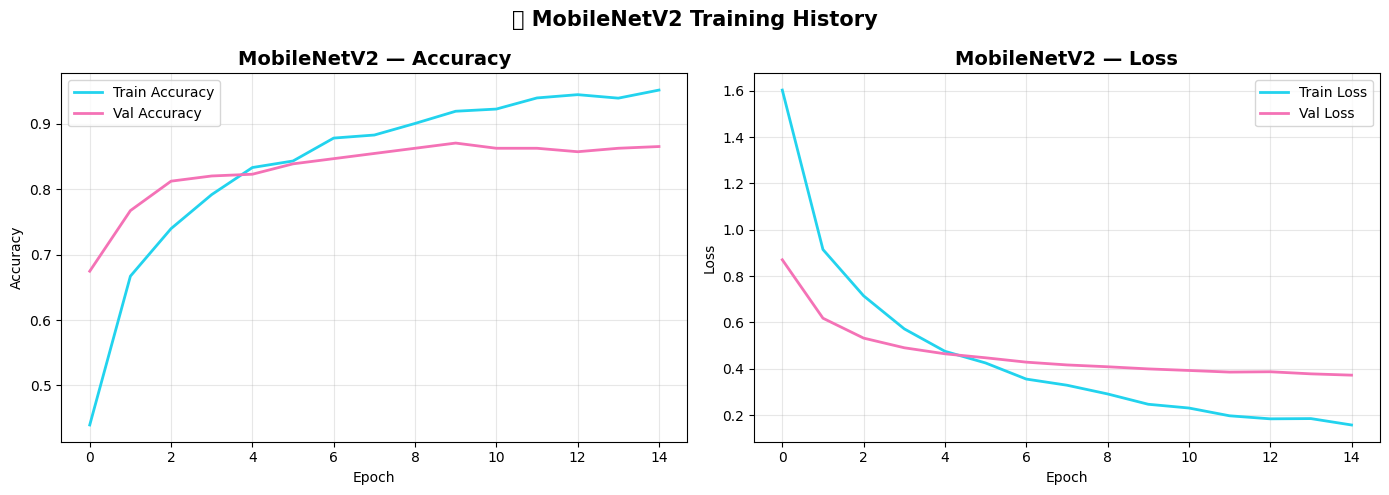

   ✅ History plot saved: D:\RecycleVision\models\MobileNetV2_history.png


In [5]:
# Cell 5 - Model 1: MobileNetV2
print('=' * 55)
print('⚡ MODEL 1: MobileNetV2')
print('=' * 55)

# --- Build Model ---
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False  # Freeze base layers

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = keras.Model(inputs, outputs, name='MobileNetV2')
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {mobilenet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in mobilenet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(mobilenet_preprocess)

# --- Train ---
print('\n🚀 Training MobileNetV2...')
mobilenet_history = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'mobilenetv2_model.h5')
mobilenet_model.save(save_path)

# --- Results ---
best_val_acc = max(mobilenet_history.history['val_accuracy'])
best_train_acc = max(mobilenet_history.history['accuracy'])
all_histories['MobileNetV2'] = mobilenet_history
all_models['MobileNetV2']    = mobilenet_model

print(f'\n✅ MobileNetV2 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(mobilenet_history, 'MobileNetV2')

## 🔲 Cell 6 — Model 2: EfficientNetB0 🎯

🎯 MODEL 2: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
   Total params    : 4,384,169
   Trainable params: 332,038
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training EfficientNetB0...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.3585 - loss: 1.8657
Epoch 1: val_accuracy improved from None to 0.79101, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5040 - loss: 1.4164 - val_accuracy: 0.7910 - val_loss: 0.8732 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.7137 - loss: 0.7630
Epoch 2: val_accuracy improved from 0.79101 to 0.83862, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7393 - loss: 0.7032 - val_accuracy: 0.8386 - val_loss: 0.5517 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.8017 - loss: 0.5754
Epoch 3: val_accuracy improved from 0.83862 to 0.84656, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8117 - loss: 0.5419 - val_accuracy: 0.8466 - val_loss: 0.4291 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.8511 - loss: 0.4439
Epoch 4: val_accuracy improved from 0.84656 to 0.87302, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 997ms/step - accuracy: 0.8497 - loss: 0.4318 - val_accuracy: 0.8730 - val_loss: 0.3637 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.8565 - loss: 0.3968
Epoch 5: val_accuracy improved from 0.87302 to 0.88624, saving model to D:\RecycleVision\models\efficientnetb0_best.h5


...


Epoch 6: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 998ms/step - accuracy: 0.8947 - loss: 0.3128 - val_accuracy: 0.8915 - val_loss: 0.3188 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.8966 - loss: 0.2903
Epoch 7: val_accuracy improved from 0.89153 to 0.90476, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 7: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 996ms/step - accuracy: 0.9000 - loss: 0.2888 - val_accuracy: 0.9048 - val_loss: 0.3063 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 872ms/step - accuracy: 0.9300 - loss: 0.2398
Epoch 8: val_accuracy did not improve from 0.90476
94/94 ━━━━━━━━━━━━━━━━━━━━ 92s 982ms/step - accuracy: 0.9303 - loss: 0.2377 - val_accuracy: 0.9048 - val_loss: 0.2990 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.9224 - loss: 0.2356
Epoch 9: val_accuracy improved from 0.90476 to 0.91005, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9203 - loss: 0.2342 - val_accuracy: 0.9101 - val_loss: 0.2856 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.9380 - loss: 0.1846
Epoch 10: val_accuracy improved from 0.91005 to 0.91534, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 10: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 93s 992ms/step - accuracy: 0.9403 - loss: 0.1875 - val_accuracy: 0.9153 - val_loss: 0.2835 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.9396 - loss: 0.1846
Epoch 11: val_accuracy did not improve from 0.91534
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9477 - loss: 0.1663 - val_accuracy: 0.9153 - val_loss: 0.2823 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.9497 - loss: 0.1678
Epoch 12: val_accuracy did not improve from 0.91534
94/94 ━━━━━━━━━━━━━━━━━━━━ 93s 984ms/step - accuracy: 0.9517 - loss: 0.1589 - val_accuracy: 0.9101 - val_loss: 0.2820 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.9481 - loss: 0.1647
Epoch 13: val_accuracy did not improve from 0.91534
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 996ms/step - accuracy: 0.9517 - lo


✅ EfficientNetB0 Training Complete!
   Best Train Accuracy : 0.9580 (95.80%)
   Best Val Accuracy   : 0.9153 (91.53%)
   Model saved         : D:\RecycleVision\models\efficientnetb0_model.h5


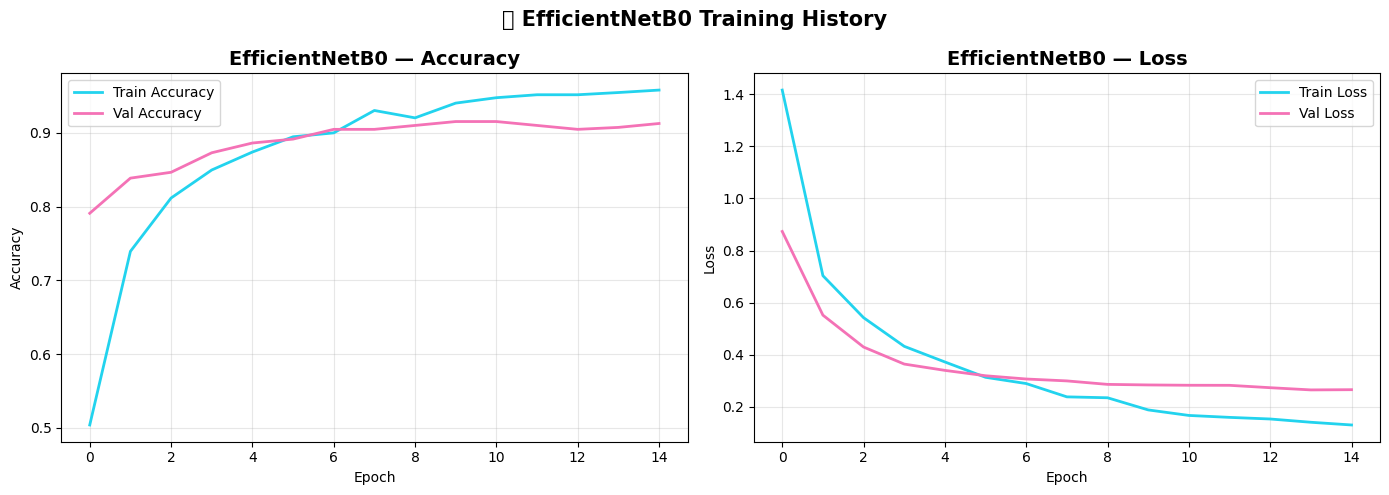

   ✅ History plot saved: D:\RecycleVision\models\EfficientNetB0_history.png


In [6]:
# Cell 6 - Model 2: EfficientNetB0
print('=' * 55)
print('🎯 MODEL 2: EfficientNetB0')
print('=' * 55)

# --- Build Model ---
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

efficientnet_model = keras.Model(inputs, outputs, name='EfficientNetB0')
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {efficientnet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in efficientnet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(efficientnet_preprocess)

# --- Train ---
print('\n🚀 Training EfficientNetB0...')
efficientnet_history = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('efficientnetb0'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'efficientnetb0_model.h5')
efficientnet_model.save(save_path)

# --- Results ---
best_val_acc   = max(efficientnet_history.history['val_accuracy'])
best_train_acc = max(efficientnet_history.history['accuracy'])
all_histories['EfficientNetB0'] = efficientnet_history
all_models['EfficientNetB0']    = efficientnet_model

print(f'\n✅ EfficientNetB0 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(efficientnet_history, 'EfficientNetB0')

## 🔲 Cell 7 — Model 3: ResNet50 🏗️

🏗️  MODEL 3: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
   Total params    : 24,648,070
   Trainable params: 1,056,262
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training ResNet50...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4158 - loss: 1.9417
Epoch 1: val_accuracy improved from None to 0.83333, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.5587 - loss: 1.3598 - val_accuracy: 0.8333 - val_loss: 0.5740 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7657 - loss: 0.6668
Epoch 2: val_accuracy improved from 0.83333 to 0.87831, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7737 - loss: 0.6340 - val_accuracy: 0.8783 - val_loss: 0.4185 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8458 - loss: 0.4529
Epoch 3: val_accuracy improved from 0.87831 to 0.89153, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.8443 - loss: 0.4503 - val_accuracy: 0.8915 - val_loss: 0.3559 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8765 - loss: 0.3354
Epoch 4: val_accuracy improved from 0.89153 to 0.90212, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.8857 - loss: 0.3199 - val_accuracy: 0.9021 - val_loss: 0.3283 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8946 - loss: 0.2846
Epoch 5: val_accuracy improved from 0.90212 to 0.91005, saving model to D:\RecycleVision\models\resnet50_best.h5


...


Epoch 12: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9710 - loss: 0.0913 - val_accuracy: 0.9259 - val_loss: 0.2824 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9815 - loss: 0.0747
Epoch 13: val_accuracy improved from 0.92593 to 0.92857, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 13: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9817 - loss: 0.0758 - val_accuracy: 0.9286 - val_loss: 0.2809 - learning_rate: 1.0000e-04
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9734 - loss: 0.0740
Epoch 14: val_accuracy improved from 0.92857 to 0.93122, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 14: finished saving model to D:\RecycleVision\models\resnet50_best.h5

Epoch 14: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9783 - loss: 0.0738 - val_accuracy: 0.9312 - val_loss: 0.2773 - learning_rate: 1.0000e-04
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9883 - loss: 0.0568
Epoch 15: val_accuracy did not improve from 0.93122
94/94 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9843 - loss: 0.0592 - val_accuracy: 0.9286 - val_loss: 0.2802 - learning_rate: 5.0000e-05
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9832 - loss: 0.0692
Epoch 16: val_accuracy did not improve from 0.93122
94/94 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9803 - loss: 0.0698 - val_accuracy: 0.9286 - val_loss: 0.2840 - learning_rate: 5.0000e-05
Epoch 17/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9869 - loss: 0.0498
Epoch 17: val_accuracy improved from 0.93122 to 0.93386, 


Epoch 17: finished saving model to D:\RecycleVision\models\resnet50_best.h5

Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9873 - loss: 0.0520 - val_accuracy: 0.9339 - val_loss: 0.2784 - learning_rate: 5.0000e-05
Epoch 18/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9891 - loss: 0.0447
Epoch 18: val_accuracy did not improve from 0.93386
94/94 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9877 - loss: 0.0496 - val_accuracy: 0.9312 - val_loss: 0.2789 - learning_rate: 2.5000e-05
Epoch 19/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9861 - loss: 0.0550
Epoch 19: val_accuracy did not improve from 0.93386
94/94 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9877 - loss: 0.0512 - val_accuracy: 0.9312 - val_loss: 0.2802 - learning_rate: 2.5000e-05
Epoch 20/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9880 - loss: 0.0507
Epoch 20: val_accuracy did not improve from 0.93386

Epoc


✅ ResNet50 Training Complete!
   Best Train Accuracy : 0.9880 (98.80%)
   Best Val Accuracy   : 0.9339 (93.39%)
   Model saved         : D:\RecycleVision\models\resnet50_model.h5


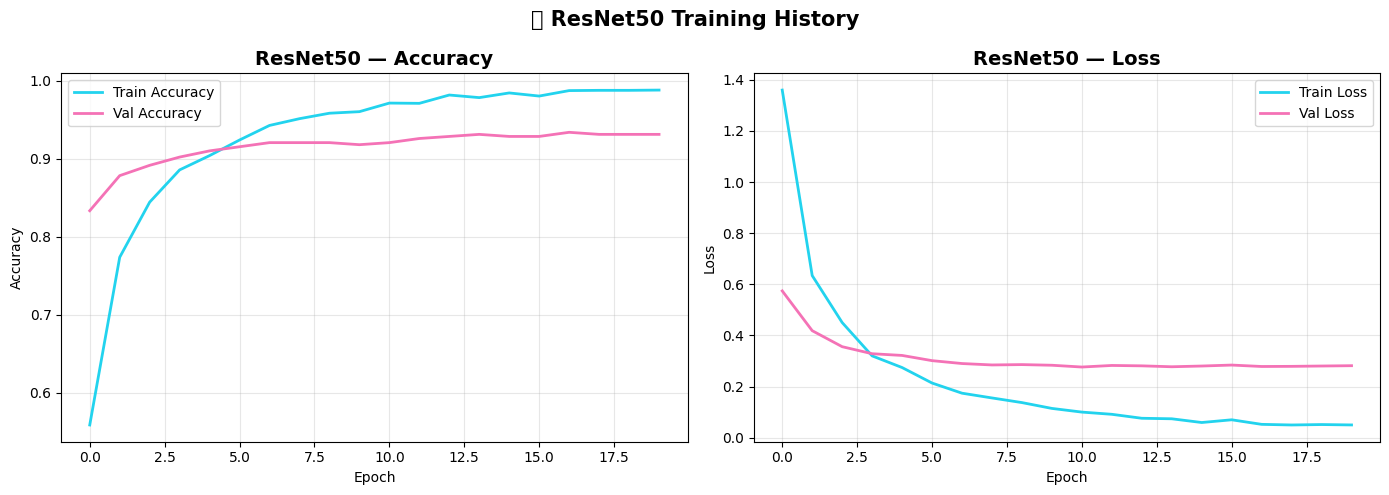

   ✅ History plot saved: D:\RecycleVision\models\ResNet50_history.png


In [7]:
# Cell 7 - Model 3: ResNet50
print('=' * 55)
print('🏗️  MODEL 3: ResNet50')
print('=' * 55)

# --- Build Model ---
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = keras.Model(inputs, outputs, name='ResNet50')
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {resnet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(resnet_preprocess)

# --- Train ---
print('\n🚀 Training ResNet50...')
resnet_history = resnet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('resnet50'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'resnet50_model.h5')
resnet_model.save(save_path)

# --- Results ---
best_val_acc   = max(resnet_history.history['val_accuracy'])
best_train_acc = max(resnet_history.history['accuracy'])
all_histories['ResNet50'] = resnet_history
all_models['ResNet50']    = resnet_model

print(f'\n✅ ResNet50 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(resnet_history, 'ResNet50')

## 🔲 Cell 8 — Model 4: VGG16 🔲

🔲 MODEL 4: VGG16
   Total params    : 27,693,126
   Trainable params: 12,978,438
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training VGG16...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3642 - loss: 8.0124
Epoch 1: val_accuracy improved from None to 0.72751, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 582s 6s/step - accuracy: 0.4620 - loss: 5.2218 - val_accuracy: 0.7275 - val_loss: 0.9819 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6807 - loss: 1.7283
Epoch 2: val_accuracy improved from 0.72751 to 0.79894, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 539s 6s/step - accuracy: 0.6900 - loss: 1.5559 - val_accuracy: 0.7989 - val_loss: 0.7383 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7930 - loss: 0.9069
Epoch 3: val_accuracy improved from 0.79894 to 0.84921, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 540s 6s/step - accuracy: 0.7897 - loss: 0.9235 - val_accuracy: 0.8492 - val_loss: 0.6507 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8495 - loss: 0.6428
Epoch 4: val_accuracy did not improve from 0.84921
94/94 ━━━━━━━━━━━━━━━━━━━━ 538s 6s/step - accuracy: 0.8430 - loss: 0.6208 - val_accuracy: 0.8307 - val_loss: 0.6907 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8582 - loss: 0.5127
Epoch 5: val_accuracy improved from 0.84921 to 0.85450, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 5: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 534s 6s/step - accuracy: 0.8580 - loss: 0.5140 - val_accuracy: 0.8545 - val_loss: 0.5908 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8827 - loss: 0.4072
Epoch 6: val_accuracy improved from 0.85450 to 0.85979, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 6: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 539s 6s/step - accuracy: 0.8963 - loss: 0.4010 - val_accuracy: 0.8598 - val_loss: 0.6223 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8886 - loss: 0.4623
Epoch 7: val_accuracy did not improve from 0.85979
94/94 ━━━━━━━━━━━━━━━━━━━━ 593s 6s/step - accuracy: 0.8987 - loss: 0.4145 - val_accuracy: 0.8598 - val_loss: 0.6298 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9185 - loss: 0.3426
Epoch 8: val_accuracy did not improve from 0.85979

Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 743s 8s/step - accuracy: 0.9220 - loss: 0.3280 - val_accuracy: 0.8571 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9328 - loss: 0.2751
Epoch 9: val_accuracy did not improve from 0.85979
94/94 ━━━━━━━━━


Epoch 11: finished saving model to D:\RecycleVision\models\vgg16_best.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 980s 10s/step - accuracy: 0.9563 - loss: 0.1629 - val_accuracy: 0.8624 - val_loss: 0.7283 - learning_rate: 5.0000e-05
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9621 - loss: 0.1747
Epoch 12: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 750s 8s/step - accuracy: 0.9590 - loss: 0.1751 - val_accuracy: 0.8519 - val_loss: 0.7264 - learning_rate: 2.5000e-05
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9597 - loss: 0.1564
Epoch 13: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 777s 8s/step - accuracy: 0.9600 - loss: 0.1526 - val_accuracy: 0.8571 - val_loss: 0.7010 - learning_rate: 2.5000e-05
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9651 - loss: 0.1642
Epoch 14: val_accuracy did not improve from 0.86243

Epoch


Epoch 15: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 764s 8s/step - accuracy: 0.9637 - loss: 0.1244 - val_accuracy: 0.8677 - val_loss: 0.6706 - learning_rate: 1.2500e-05
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9712 - loss: 0.0977
Epoch 16: val_accuracy did not improve from 0.86772
94/94 ━━━━━━━━━━━━━━━━━━━━ 738s 8s/step - accuracy: 0.9653 - loss: 0.1174 - val_accuracy: 0.8677 - val_loss: 0.6627 - learning_rate: 1.2500e-05
Epoch 17/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9707 - loss: 0.1093 
Epoch 17: val_accuracy did not improve from 0.86772

Epoch 17: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
94/94 ━━━━━━━━━━━━━━━━━━━━ 1039s 11s/step - accuracy: 0.9710 - loss: 0.1046 - val_accuracy: 0.8651 - val_loss: 0.6625 - learning_rate: 1.2500e-05
Epoch 18/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9674 - loss: 0.1079
Epoch 18: val_accuracy improved from 0.86772 to 0.87302, 


Epoch 18: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 860s 9s/step - accuracy: 0.9740 - loss: 0.1025 - val_accuracy: 0.8730 - val_loss: 0.6710 - learning_rate: 6.2500e-06
Epoch 19/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9741 - loss: 0.0843
Epoch 19: val_accuracy did not improve from 0.87302
94/94 ━━━━━━━━━━━━━━━━━━━━ 829s 9s/step - accuracy: 0.9753 - loss: 0.0799 - val_accuracy: 0.8704 - val_loss: 0.6798 - learning_rate: 6.2500e-06
Epoch 20/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9723 - loss: 0.1025
Epoch 20: val_accuracy did not improve from 0.87302

Epoch 20: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
94/94 ━━━━━━━━━━━━━━━━━━━━ 997s 11s/step - accuracy: 0.9763 - loss: 0.0835 - val_accuracy: 0.8651 - val_loss: 0.6854 - learning_rate: 6.2500e-06
Restoring model weights from the end of the best epoch: 18.



✅ VGG16 Training Complete!
   Best Train Accuracy : 0.9763 (97.63%)
   Best Val Accuracy   : 0.8730 (87.30%)
   Model saved         : D:\RecycleVision\models\vgg16_model.h5


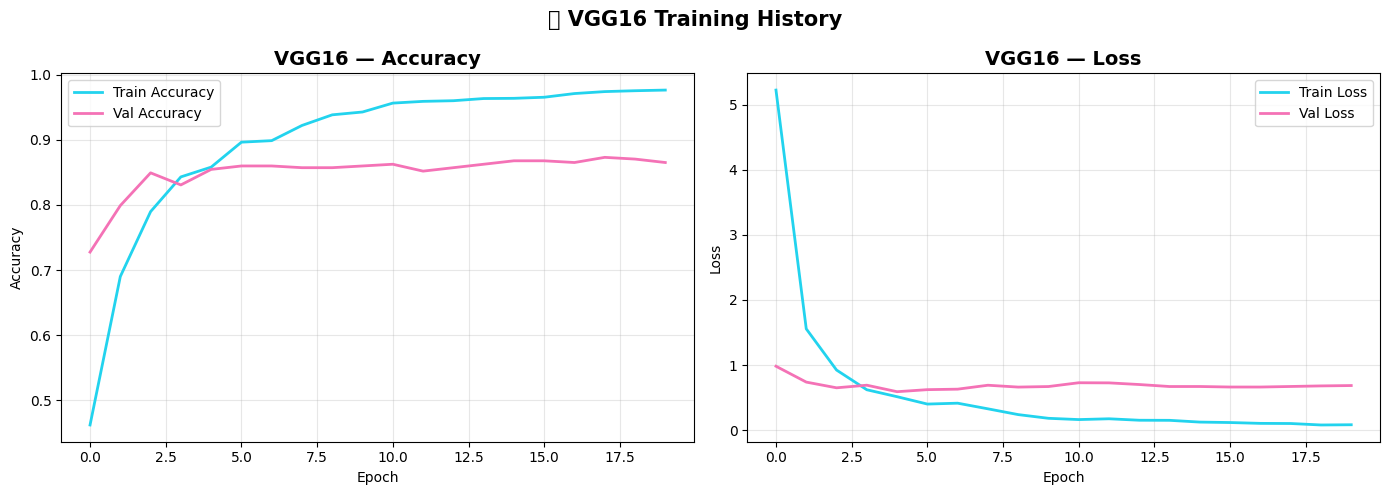

   ✅ History plot saved: D:\RecycleVision\models\VGG16_history.png


In [10]:
# Cell 8 - Model 4: VGG16
print('=' * 55)
print('🔲 MODEL 4: VGG16')
print('=' * 55)

# --- Build Model ---
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.Flatten()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg16_model = keras.Model(inputs, outputs, name='VGG16')
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {vgg16_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in vgg16_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(vgg16_preprocess)

# --- Train ---
print('\n🚀 Training VGG16...')
vgg16_history = vgg16_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('vgg16'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'vgg16_model.h5')
vgg16_model.save(save_path)

# --- Results ---
best_val_acc   = max(vgg16_history.history['val_accuracy'])
best_train_acc = max(vgg16_history.history['accuracy'])
all_histories['VGG16'] = vgg16_history
all_models['VGG16']    = vgg16_model

print(f'\n✅ VGG16 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(vgg16_history, 'VGG16')

## 🔲 Cell 9 — Model 5: InceptionV3 🌀

🌀 MODEL 5: InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
   Total params    : 22,863,142
   Trainable params: 1,056,262
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training InceptionV3...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4130 - loss: 1.8363
Epoch 1: val_accuracy improved from None to 0.73810, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.5473 - loss: 1.3431 - val_accuracy: 0.7381 - val_loss: 0.7419 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7674 - loss: 0.6522
Epoch 2: val_accuracy improved from 0.73810 to 0.77778, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.7747 - loss: 0.6368 - val_accuracy: 0.7778 - val_loss: 0.5907 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8382 - loss: 0.4600
Epoch 3: val_accuracy improved from 0.77778 to 0.79894, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8383 - loss: 0.4505 - val_accuracy: 0.7989 - val_loss: 0.5340 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8613 - loss: 0.3785
Epoch 4: val_accuracy improved from 0.79894 to 0.80688, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.8727 - loss: 0.3571 - val_accuracy: 0.8069 - val_loss: 0.4973 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9028 - loss: 0.2748
Epoch 5: val_accuracy improved from 0.80688 to 0.82804, saving model to D:\RecycleVision\models\inceptionv3_best.h5


...


Epoch 9: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9620 - loss: 0.1301 - val_accuracy: 0.8307 - val_loss: 0.4658 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9770 - loss: 0.0961
Epoch 10: val_accuracy improved from 0.83069 to 0.83598, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 10: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9720 - loss: 0.1061 - val_accuracy: 0.8360 - val_loss: 0.4632 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9825 - loss: 0.0784
Epoch 11: val_accuracy improved from 0.83598 to 0.83862, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 11: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9797 - loss: 0.0857 - val_accuracy: 0.8386 - val_loss: 0.4582 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9839 - loss: 0.0746
Epoch 12: val_accuracy improved from 0.83862 to 0.85714, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 12: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9810 - loss: 0.0804 - val_accuracy: 0.8571 - val_loss: 0.4556 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9842 - loss: 0.0772
Epoch 13: val_accuracy did not improve from 0.85714
94/94 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9857 - loss: 0.0745 - val_accuracy: 0.8386 - val_loss: 0.4733 - learning_rate: 1.0000e-04
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9907 - loss: 0.0572
Epoch 14: val_accuracy did not improve from 0.85714
94/94 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9880 - loss: 0.0670 - val_accuracy: 0.8413 - val_loss: 0.4655 - learning_rate: 1.0000e-04
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9867 - loss: 0.0590
Epoch 15: val_accuracy did not improve from 0.85714

Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94


✅ InceptionV3 Training Complete!
   Best Train Accuracy : 0.9920 (99.20%)
   Best Val Accuracy   : 0.8571 (85.71%)
   Model saved         : D:\RecycleVision\models\inceptionv3_model.h5


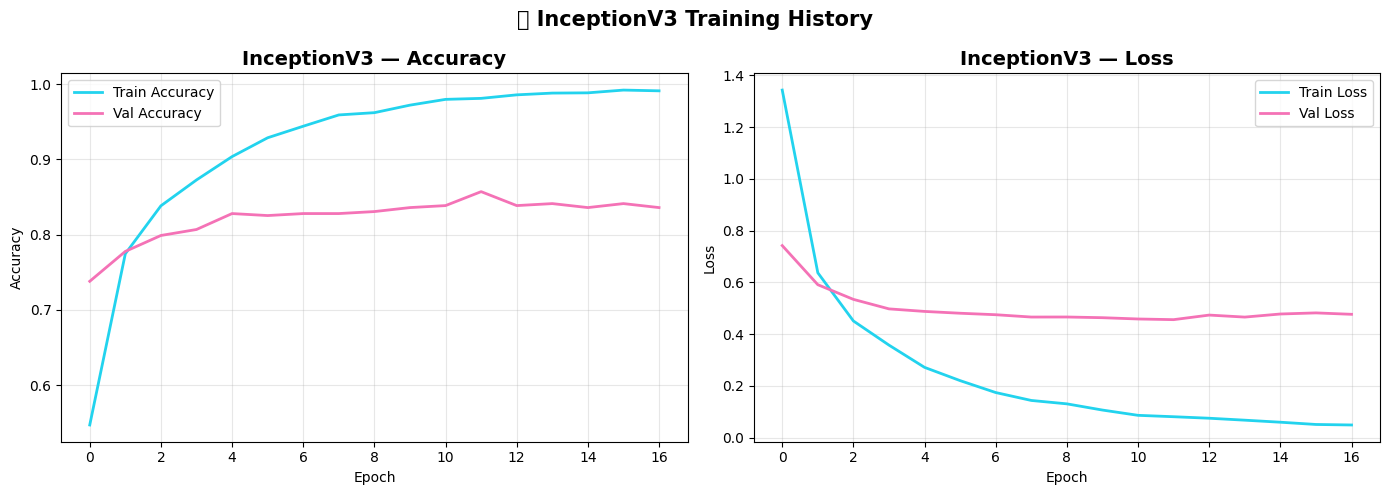

   ✅ History plot saved: D:\RecycleVision\models\InceptionV3_history.png


In [11]:
# Cell 9 - Model 5: InceptionV3
# Note: InceptionV3 requires minimum 75x75 input — we use 224x224 which is fine
print('=' * 55)
print('🌀 MODEL 5: InceptionV3')
print('=' * 55)

# --- Build Model ---
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

inception_model = keras.Model(inputs, outputs, name='InceptionV3')
inception_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {inception_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in inception_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(inception_preprocess)

# --- Train ---
print('\n🚀 Training InceptionV3...')
inception_history = inception_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('inceptionv3'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'inceptionv3_model.h5')
inception_model.save(save_path)

# --- Results ---
best_val_acc   = max(inception_history.history['val_accuracy'])
best_train_acc = max(inception_history.history['accuracy'])
all_histories['InceptionV3'] = inception_history
all_models['InceptionV3']    = inception_model

print(f'\n✅ InceptionV3 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(inception_history, 'InceptionV3')

## 🔲 Cell 10 — All Models Comparison Table & Chart

         🏆 ALL 5 MODELS — TRAINING COMPARISON
         Model  Train Acc (%)  Val Acc (%)  Train Loss  Val Loss  Epochs
      ResNet50          98.80        93.39      0.0496    0.2763      20
EfficientNetB0          95.80        91.53      0.1296    0.2644      15
         VGG16          97.63        87.30      0.0799    0.5908      20
   MobileNetV2          95.13        87.04      0.1572    0.3723      15
   InceptionV3          99.20        85.71      0.0484    0.4556      17
🏆 BEST MODEL (Val Accuracy) : ResNet50 (93.39%)


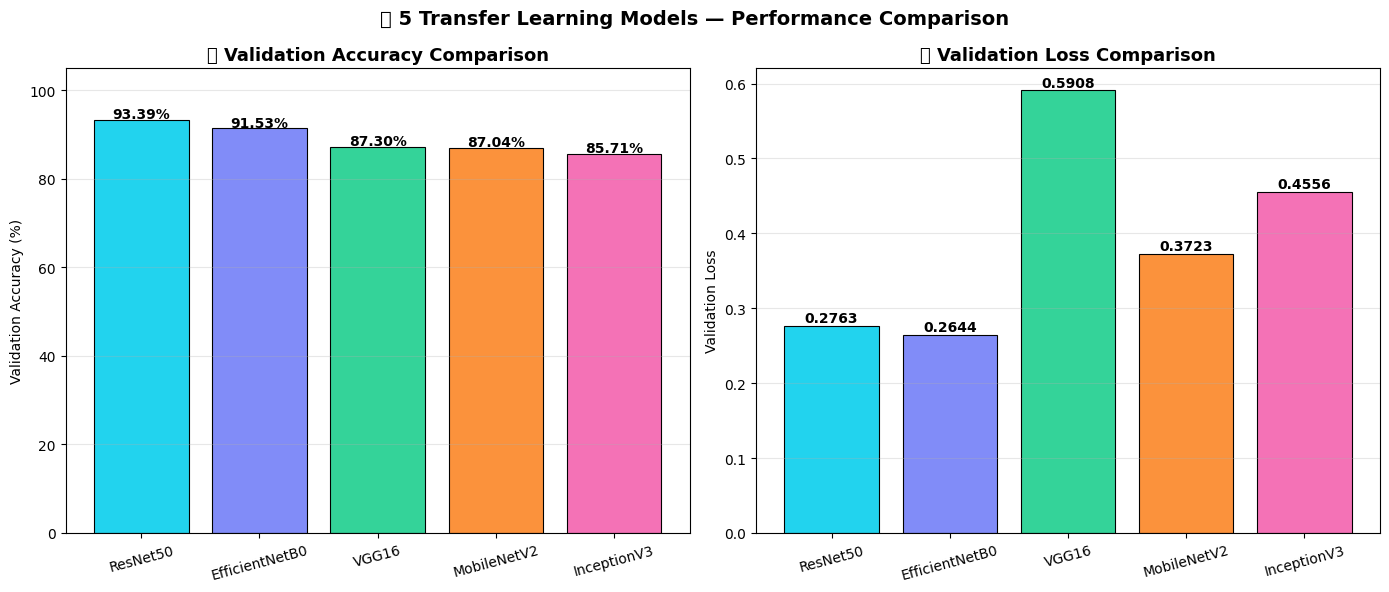

✅ Comparison chart saved: D:\RecycleVision\models\model_comparison.png


In [12]:
# Cell 10 - Final Comparison Table & Bar Chart
print('=' * 65)
print('         🏆 ALL 5 MODELS — TRAINING COMPARISON')
print('=' * 65)

comparison_data = []
model_colors    = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6']

for model_name, history in all_histories.items():
    best_train_acc = max(history.history['accuracy'])     * 100
    best_val_acc   = max(history.history['val_accuracy']) * 100
    best_train_loss = min(history.history['loss'])
    best_val_loss   = min(history.history['val_loss'])
    epochs_trained  = len(history.history['accuracy'])

    comparison_data.append({
        'Model'          : model_name,
        'Train Acc (%)' : round(best_train_acc, 2),
        'Val Acc (%)'   : round(best_val_acc,   2),
        'Train Loss'    : round(best_train_loss, 4),
        'Val Loss'      : round(best_val_loss,   4),
        'Epochs'        : epochs_trained
    })

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values('Val Acc (%)', ascending=False).reset_index(drop=True)

print(df_compare.to_string(index=False))
print('=' * 65)
best_model = df_compare.iloc[0]['Model']
best_acc   = df_compare.iloc[0]['Val Acc (%)']
print(f'🏆 BEST MODEL (Val Accuracy) : {best_model} ({best_acc}%)')
print('=' * 65)

# --- Bar Chart Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Val Accuracy
bars = axes[0].bar(
    df_compare['Model'],
    df_compare['Val Acc (%)'],
    color=model_colors, edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, df_compare['Val Acc (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('📊 Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Val Loss
bars2 = axes[1].bar(
    df_compare['Model'],
    df_compare['Val Loss'],
    color=model_colors, edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars2, df_compare['Val Loss']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('📊 Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Validation Loss')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('🏆 5 Transfer Learning Models — Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(MODELS_PATH, 'model_comparison.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ Comparison chart saved: {save_path}')

## 🔲 Cell 11 — Verify All Models Saved

In [14]:
# Cell 11 - Verify All Saved Models
print('=' * 55)
print('💾 SAVED MODELS IN models/ FOLDER')
print('=' * 55)

saved_files = os.listdir(MODELS_PATH)
total_size  = 0

for fname in sorted(saved_files):
    fpath     = os.path.join(MODELS_PATH, fname)
    size_mb   = os.path.getsize(fpath) / (1024 * 1024)
    total_size += size_mb
    print(f'  ✅ {fname:<35} {size_mb:.1f} MB')

print('=' * 55)
print(f'  Total size : {total_size:.1f} MB')
print('=' * 55)
print()
print('=' * 55)
print('   ✅ MODEL TRAINING COMPLETE!')
print('=' * 55)
print(f'  5 models trained and saved')
print(f'  Best model so far : {best_model} ({best_acc:.2f}% val accuracy)')
print()
print('🔜 Next Step: Model Evaluation (04_Model_Evaluation.ipynb)')
print('   → Accuracy, Precision, Recall, F1-Score')
print('   → Confusion Matrix for each model')
print('   → Final best model selection')
print('=' * 55)

💾 SAVED MODELS IN models/ FOLDER
  ✅ EfficientNetB0_history.png          0.1 MB
  ✅ InceptionV3_history.png             0.1 MB
  ✅ MobileNetV2_history.png             0.1 MB
  ✅ ResNet50_history.png                0.1 MB
  ✅ VGG16_history.png                   0.1 MB
  ✅ efficientnetb0_best.h5              19.7 MB
  ✅ efficientnetb0_model.h5             19.7 MB
  ✅ inceptionv3_best.h5                 95.9 MB
  ✅ inceptionv3_model.h5                95.9 MB
  ✅ mobilenetv2_best.h5                 12.8 MB
  ✅ mobilenetv2_model.h5                12.8 MB
  ✅ model_comparison.png                0.1 MB
  ✅ resnet50_best.h5                    102.5 MB
  ✅ resnet50_model.h5                   102.5 MB
  ✅ vgg16_best.h5                       204.7 MB
  ✅ vgg16_model.h5                      204.7 MB
  Total size : 871.7 MB

   ✅ MODEL TRAINING COMPLETE!
  5 models trained and saved
  Best model so far : ResNet50 (93.39% val accuracy)

🔜 Next Step: Model Evaluation (04_Model_Evaluation.ipynb)
   → 